подготовительные действияв

In [1]:
import sys, os
if not os.environ.get("DISPLAY"):
    os.environ['DISPLAY'] = ':1'

import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math

Класс QLearningAgent

In [2]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return 0.0
        return max(self.get_qvalue(state, a) for a in actions)

    def update(self, state, action, reward, next_state):
        old_q = self.get_qvalue(state, action)
        td_target = reward + self.discount * self.get_value(next_state)
        updated_q = old_q + self.alpha * (td_target - old_q)
        self.set_qvalue(state, action, updated_q)

    def get_best_action(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return None
        return max(actions, key=lambda a: self.get_qvalue(state, a))

    def get_action(self, state):
        actions = self.get_legal_actions(state)
        if not actions:
            return None

        if random.random() < self.epsilon:
            return random.choice(actions)
        return self.get_best_action(state)

In [3]:
import gymnasium as gym

env = gym.make("Taxi-v3")
n_actions = env.action_space.n

agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions)
)

def play_and_train(env, agent, t_max=10**4):
    total_reward = 0.0
    obs = env.reset()
    s = obs[0] if isinstance(obs, tuple) else obs

    for t in range(t_max):
        a = agent.get_action(s)
        result = env.step(a)

        if len(result) == 5:
            next_s, r, terminated, truncated, _ = result
            done = terminated or truncated
        else:
            next_s, r, done, _ = result

        if isinstance(next_s, tuple):
            next_s = next_s[0]

        agent.update(s, a, r, next_s)
        s = next_s
        total_reward += r

        if done:
            break

    return total_reward

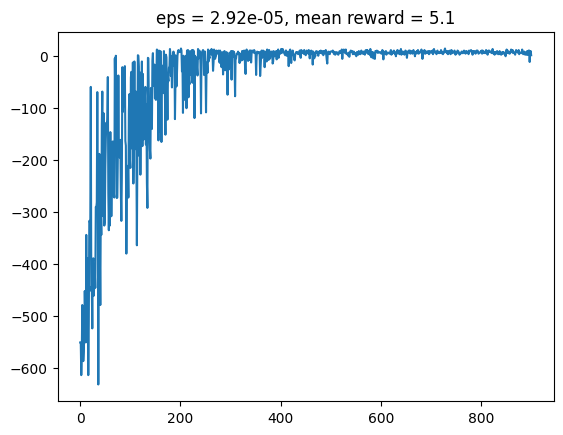

In [4]:
from IPython.display import clear_output

rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99

    if i % 100 == 0:
        clear_output(True)
        plt.title(f'eps = {agent.epsilon:.2e}, mean reward = {np.mean(rewards[-10:]):.1f}')
        plt.plot(rewards)
        plt.show()

Бинаризованные пространства состояний

начальное состояние: [-0.04951774 -0.02418125  0.00667973  0.01070121]


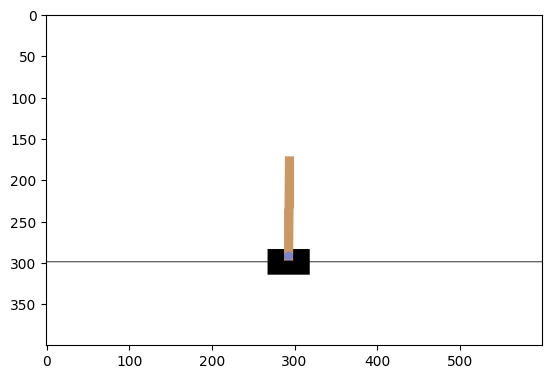

In [5]:
def make_env():
    return gym.make('CartPole-v1', render_mode='rgb_array')

env = make_env()
obs, info = env.reset()
print(f"начальное состояние: {obs}")
plt.imshow(env.render())

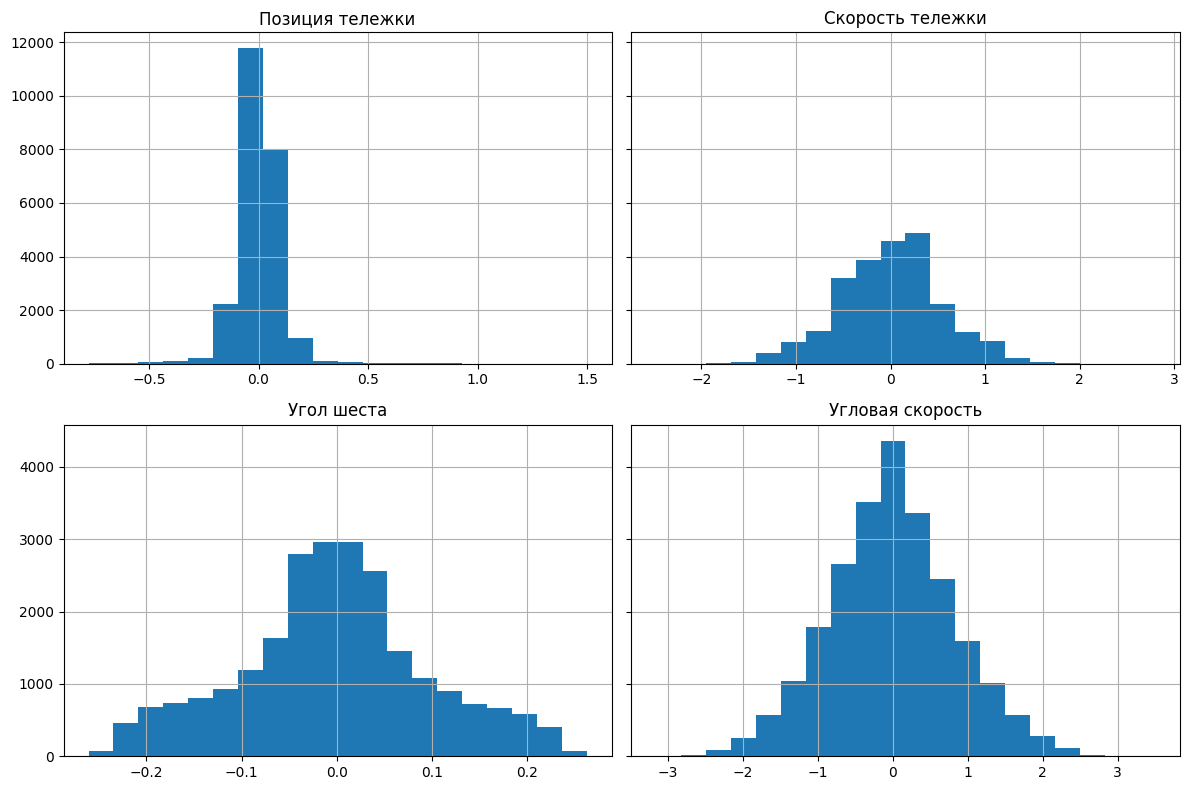

In [6]:
import matplotlib.pyplot as plt
import numpy as np

all_observations = []
for _ in range(1000):
    obs, _ = env.reset()
    all_observations.append(obs)

    terminated, truncated = False, False
    while not (terminated or truncated):
        action = env.action_space.sample()
        obs, r, terminated, truncated, _ = env.step(action)
        all_observations.append(obs)

all_observations = np.array(all_observations)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
names = ["Позиция тележки", "Скорость тележки", "Угол шеста", "Угловая скорость"]

for idx, ax in enumerate(axes.flatten()):
    ax.hist(all_observations[:, idx], bins=20)
    ax.set_title(names[idx])
    ax.grid(True)

plt.tight_layout()
plt.show()

Бинаризованная среда

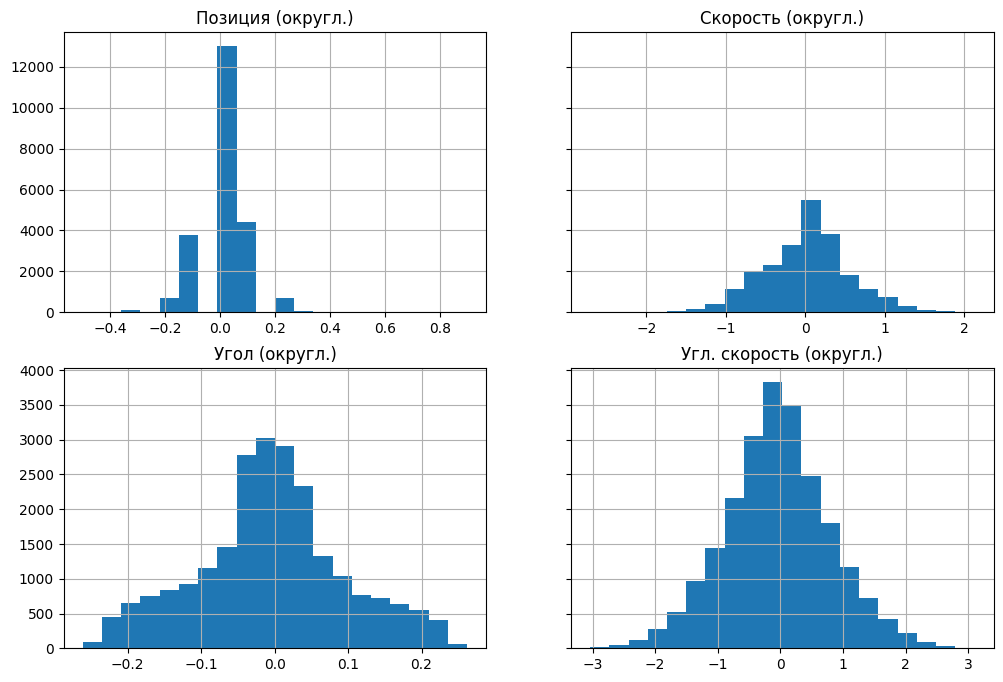

In [7]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import ObservationWrapper


class Binarizer(ObservationWrapper):
    def observation(self, state):
        precision = [1, 2, 3, 2]
        return tuple(round(val, p) for val, p in zip(state, precision))


env2 = Binarizer(gym.make('CartPole-v1'))

all_obs = []
for _ in range(1000):
    obs, _ = env2.reset()
    all_obs.append(obs)

    terminated, truncated = False, False
    while not (terminated or truncated):
        action = env2.action_space.sample()
        obs, r, terminated, truncated, _ = env2.step(action)
        all_obs.append(obs)

all_obs = np.array(all_obs)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
names = [
    "Позиция (округл.)",
    "Скорость (округл.)",
    "Угол (округл.)",
    "Угл. скорость (округл.)"
]

for idx, ax in enumerate(axes.flatten()):
    ax.hist(all_obs[:, idx], bins=20)
    ax.set_title(names[idx])
    ax.grid(True)